In [30]:
"""
Monte Carlo Cross-Validation (MCCV) para Classificação de Leucemia
Baseado no código original de CNN com adaptações para validação Monte Carlo
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import timm
import pickle
import json
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import time
from scipy import stats
warnings.filterwarnings('ignore')

In [31]:
# ===================== CONFIGURAÇÕES MONTE CARLO =====================
MONTE_CARLO_ITERATIONS = 100  # Número de iterações Monte Carlo
TEST_SIZE = 0.2  # Proporção para teste em cada iteração
VAL_SIZE = 0.15  # Proporção para validação do conjunto de treino
RANDOM_SEED_BASE = 42  # Seed base para reprodutibilidade

# Configurações do modelo (importadas do config original)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_CLASSES = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS_PER_ITERATION = 30  # Menos epochs por iteração já que faremos 100x

# Diretórios
TRAIN_DIR = 'dataset/cnmc2019_splits/images/train'
VAL_DIR = 'dataset/cnmc2019_splits/images/val'
TEST_DIR = 'dataset/cnmc2019_splits/images/test'
SAVE_DIR = 'monte_carlo_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# Modelos a testar
CNN_MODELS = [
    'tf_efficientnetv2_b3'
]

In [32]:
# ===================== DATASET (Adaptado) =====================
class LeukemiaDatasetMC(Dataset):
    """Dataset adaptado para Monte Carlo - carrega TODAS as imagens de todos os splits"""
    def __init__(self, dirs_list=None, transform=None):
        """
        dirs_list: lista de diretórios para carregar (train, val, test)
        """
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Se não especificar, carrega todos os diretórios
        if dirs_list is None:
            dirs_list = [TRAIN_DIR, VAL_DIR, TEST_DIR]
        
        for data_dir in dirs_list:
            # Carregar imagens ALL (classe 1)
            all_dir = os.path.join(data_dir, 'all')
            if os.path.exists(all_dir):
                for img_name in os.listdir(all_dir):
                    if img_name.endswith(('.jpg', '.png', '.bmp')):
                        self.images.append(os.path.join(all_dir, img_name))
                        self.labels.append(1)
            
            # Carregar imagens HEM (classe 0)
            hem_dir = os.path.join(data_dir, 'hem')
            if os.path.exists(hem_dir):
                for img_name in os.listdir(hem_dir):
                    if img_name.endswith(('.jpg', '.png', '.bmp')):
                        self.images.append(os.path.join(hem_dir, img_name))
                        self.labels.append(0)
        
        print(f"Dataset carregado: {len(self.images)} imagens")
        print(f"Distribuição - ALL: {self.labels.count(1)}, HEM: {self.labels.count(0)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [33]:
# ===================== TRANSFORMAÇÕES =====================
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

In [34]:
# ===================== MODELO (do código original) =====================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CNNModel(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='',
            drop_rate=0.3,
            drop_path_rate=0.2
        )
        
        num_features = self.backbone.num_features
        
        self.attention = SEBlock(num_features, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        features = self.attention(features)
        features = self.global_pool(features).flatten(1)
        return self.classifier(features)

In [35]:
# ===================== FOCAL LOSS =====================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        targets_one_hot = F.one_hot(targets, self.num_classes).float()
        alpha_t = self.alpha * targets_one_hot[:, 1] + (1 - self.alpha) * targets_one_hot[:, 0]
        
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [36]:

# ===================== FUNÇÕES DE TREINAMENTO =====================
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, acc, f1

def validate(model, loader, criterion, device, return_predictions=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    
    # Calcular AUC se for binário
    try:
        auc = roc_auc_score(all_targets, [p[1] for p in all_probs])
    except:
        auc = 0.0
    
    metrics = {
        'loss': avg_loss,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc
    }
    
    if return_predictions:
        return metrics, all_preds, all_targets
    return metrics

In [37]:
# ===================== MONTE CARLO CROSS-VALIDATION =====================
def monte_carlo_iteration(model_name, dataset, iteration_num, seed):
    """Executa uma iteração do Monte Carlo CV"""
    
    print(f"\n{'='*20} Iteração {iteration_num + 1}/{MONTE_CARLO_ITERATIONS} {'='*20}")
    
    # Set seed para esta iteração
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Dividir dados aleatoriamente
    indices = list(range(len(dataset)))
    labels = [dataset.labels[i] for i in indices]
    
    # Estratificação para manter proporção das classes
    train_val_idx, test_idx = train_test_split(
        indices, test_size=TEST_SIZE, 
        stratify=labels, random_state=seed
    )
    
    # Dividir train_val em train e validation
    train_val_labels = [labels[i] for i in train_val_idx]
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=VAL_SIZE,
        stratify=train_val_labels, random_state=seed
    )
    
    print(f"Split: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")
    
    # Criar data loaders
    train_transform, val_transform = get_transforms()
    
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler = SubsetRandomSampler(val_idx)
    test_sampler = SubsetRandomSampler(test_idx)
    
    # Carregar todos os dados uma única vez
    all_dirs = [TRAIN_DIR, VAL_DIR, TEST_DIR]
    
    # Dataset com augmentation para treino
    train_dataset = LeukemiaDatasetMC(dirs_list=all_dirs, transform=train_transform)
    
    # Datasets sem augmentation para validação e teste
    val_dataset = LeukemiaDatasetMC(dirs_list=all_dirs, transform=val_transform)
    test_dataset = LeukemiaDatasetMC(dirs_list=all_dirs, transform=val_transform)
    
    # Os samplers garantem que cada loader acessa apenas seus índices específicos
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                             sampler=train_sampler, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                           sampler=val_sampler, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                            sampler=test_sampler, num_workers=NUM_WORKERS)
    
    # Criar e treinar modelo
    model = CNNModel(model_name, NUM_CLASSES).to(DEVICE)
    criterion = FocalLoss(alpha=0.25, gamma=2.0, num_classes=NUM_CLASSES)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    
    # CORREÇÃO: Remover verbose=False
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    scaler = GradScaler() if DEVICE.type == 'cuda' else None
    
    # Treinamento
    best_val_f1 = 0
    best_model_state = None
    
    for epoch in range(EPOCHS_PER_ITERATION):
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        
        val_metrics = validate(model, val_loader, criterion, DEVICE)
        
        scheduler.step(val_metrics['loss'])
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train F1={train_f1:.3f}, Val F1={val_metrics['f1']:.3f}")
    
    # Testar com melhor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    test_metrics, test_preds, test_targets = validate(
        model, test_loader, criterion, DEVICE, return_predictions=True
    )
    
    # Calcular matriz de confusão
    cm = confusion_matrix(test_targets, test_preds)
    
    # Preparar resultados da iteração
    iteration_results = {
        'iteration': iteration_num,
        'seed': seed,
        'model_name': model_name,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'test_size': len(test_idx),
        'best_val_f1': best_val_f1,
        'test_metrics': test_metrics,
        'confusion_matrix': cm.tolist(),
        'train_indices': train_idx,
        'val_indices': val_idx,
        'test_indices': test_idx
    }
    
    # Limpar memória
    del model
    torch.cuda.empty_cache()
    
    return iteration_results

In [38]:
def run_monte_carlo_cv(model_name, dataset):
    """Executa validação Monte Carlo completa para um modelo"""
    
    print(f"\n{'='*50}")
    print(f"INICIANDO MONTE CARLO CV PARA: {model_name}")
    print(f"{'='*50}")
    
    all_results = []
    start_time = time.time()
    
    for i in range(MONTE_CARLO_ITERATIONS):
        seed = RANDOM_SEED_BASE + i
        iteration_result = monte_carlo_iteration(model_name, dataset, i, seed)
        all_results.append(iteration_result)
        
        # Salvar checkpoint a cada 10 iterações
        if (i + 1) % 10 == 0:
            checkpoint_path = os.path.join(
                SAVE_DIR, 
                f'{model_name.replace("/", "_")}_checkpoint_{i+1}.pkl'
            )
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_results, f)
            print(f"Checkpoint salvo: {checkpoint_path}")
    
    elapsed_time = time.time() - start_time
    
    # Análise estatística dos resultados
    test_metrics_list = [r['test_metrics'] for r in all_results]
    
    statistics = {}
    for metric in ['accuracy', 'f1', 'precision', 'recall', 'auc']:
        values = [m[metric] for m in test_metrics_list]
        statistics[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values),
            'q25': np.percentile(values, 25),
            'q75': np.percentile(values, 75),
            'ci95_lower': np.percentile(values, 2.5),
            'ci95_upper': np.percentile(values, 97.5),
            'values': values
        }
    
    # Resultado final
    final_results = {
        'model_name': model_name,
        'monte_carlo_iterations': MONTE_CARLO_ITERATIONS,
        'elapsed_time_seconds': elapsed_time,
        'statistics': statistics,
        'all_iterations': all_results,
        'timestamp': datetime.now().isoformat()
    }
    
    # Salvar resultados completos
    results_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_mc_results.pkl')
    with open(results_path, 'wb') as f:
        pickle.dump(final_results, f)
    
    # Salvar resumo em JSON (sem os valores completos)
    summary = {
        'model_name': model_name,
        'monte_carlo_iterations': MONTE_CARLO_ITERATIONS,
        'elapsed_time_seconds': elapsed_time,
        'statistics': {
            metric: {k: v for k, v in stats.items() if k != 'values'}
            for metric, stats in statistics.items()
        }
    }
    
    json_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_mc_summary.json')
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=2)
    
    return final_results

In [39]:
# ===================== VISUALIZAÇÃO DOS RESULTADOS =====================
def plot_monte_carlo_results(results_dict):
    """Cria visualizações dos resultados Monte Carlo"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Monte Carlo Cross-Validation Results', fontsize=16, y=1.02)
    
    metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#DDA0DD']
    
    for idx, (ax, metric) in enumerate(zip(axes.flat[:5], metrics)):
        data_to_plot = []
        labels = []
        
        for model_name, results in results_dict.items():
            data_to_plot.append(results['statistics'][metric]['values'])
            labels.append(model_name.replace('_', ' ').title())
        
        # Box plot
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                        showmeans=True, meanline=True)
        
        # Colorir boxes
        for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel(metric.capitalize(), fontsize=11)
        ax.set_title(f'{metric.upper()} Distribution', fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Tabela de resumo no último subplot
    ax_table = axes.flat[5]
    ax_table.axis('tight')
    ax_table.axis('off')
    
    # Criar dados para tabela
    table_data = []
    headers = ['Model', 'F1 (mean±std)', 'Acc (mean±std)', 'AUC (mean±std)']
    
    for model_name, results in results_dict.items():
        row = [
            model_name.replace('_', ' ').title(),
            f"{results['statistics']['f1']['mean']:.3f}±{results['statistics']['f1']['std']:.3f}",
            f"{results['statistics']['accuracy']['mean']:.3f}±{results['statistics']['accuracy']['std']:.3f}",
            f"{results['statistics']['auc']['mean']:.3f}±{results['statistics']['auc']['std']:.3f}"
        ]
        table_data.append(row)
    
    table = ax_table.table(cellText=table_data, colLabels=headers,
                           cellLoc='center', loc='center',
                           colColours=['lightgray']*len(headers))
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'monte_carlo_results_visualization.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Visualização salva em: {save_path}")
    plt.show()

In [40]:

def plot_convergence_analysis(results_dict):
    """Analisa a convergência das métricas ao longo das iterações"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Convergence Analysis - Running Mean and Std', fontsize=14)
    
    for model_name, results in results_dict.items():
        f1_values = results['statistics']['f1']['values']
        
        # Calcular média e desvio padrão cumulativos
        running_mean = np.array([np.mean(f1_values[:i+1]) for i in range(len(f1_values))])
        running_std = np.array([np.std(f1_values[:i+1]) if i > 0 else 0 
                                for i in range(len(f1_values))])
        
        iterations = range(1, len(f1_values) + 1)
        
        # Plot média
        axes[0].plot(iterations, running_mean, label=model_name, linewidth=2)
        axes[0].set_xlabel('Monte Carlo Iteration')
        axes[0].set_ylabel('Running Mean F1-Score')
        axes[0].set_title('Convergence of Mean F1-Score')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot desvio padrão
        axes[1].plot(iterations, running_std, label=model_name, linewidth=2)
        axes[1].set_xlabel('Monte Carlo Iteration')
        axes[1].set_ylabel('Running Std F1-Score')
        axes[1].set_title('Convergence of Std F1-Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, 'convergence_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Análise de convergência salva em: {save_path}")
    plt.show()

In [41]:
def generate_final_report(all_results):
    """Gera relatório final em formato markdown"""
    
    report = []
    report.append("# Monte Carlo Cross-Validation Report\n")
    report.append(f"**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    report.append(f"**Iterations:** {MONTE_CARLO_ITERATIONS}\n")
    report.append(f"**Test Size:** {TEST_SIZE*100:.0f}%\n\n")
    
    report.append("## Summary Results\n\n")
    
    # Tabela de resultados
    report.append("| Model | F1-Score | Accuracy | Precision | Recall | AUC |\n")
    report.append("|-------|----------|----------|-----------|--------|-----|\n")
    
    for model_name, results in all_results.items():
        stats = results['statistics']
        report.append(f"| {model_name} | "
                     f"{stats['f1']['mean']:.3f}±{stats['f1']['std']:.3f} | "
                     f"{stats['accuracy']['mean']:.3f}±{stats['accuracy']['std']:.3f} | "
                     f"{stats['precision']['mean']:.3f}±{stats['precision']['std']:.3f} | "
                     f"{stats['recall']['mean']:.3f}±{stats['recall']['std']:.3f} | "
                     f"{stats['auc']['mean']:.3f}±{stats['auc']['std']:.3f} |\n")
    
    report.append("\n## 95% Confidence Intervals\n\n")
    report.append("| Model | Metric | 95% CI |\n")
    report.append("|-------|--------|--------|\n")
    
    for model_name, results in all_results.items():
        for metric in ['f1', 'accuracy']:
            stats = results['statistics'][metric]
            report.append(f"| {model_name} | {metric} | "
                         f"[{stats['ci95_lower']:.4f}, {stats['ci95_upper']:.4f}] |\n")
    
    # Salvar relatório
    report_path = os.path.join(SAVE_DIR, 'monte_carlo_report.md')
    with open(report_path, 'w') as f:
        f.writelines(report)
    
    print(f"📄 Relatório salvo em: {report_path}")

In [42]:
# ===================== FUNÇÃO PRINCIPAL =====================
def main():
    print("="*60)
    print("MONTE CARLO CROSS-VALIDATION PARA CLASSIFICAÇÃO DE LEUCEMIA")
    print("="*60)
    print(f"Configuração:")
    print(f"- Iterações Monte Carlo: {MONTE_CARLO_ITERATIONS}")
    print(f"- Split: {(1-TEST_SIZE)*100:.0f}% treino+val, {TEST_SIZE*100:.0f}% teste")
    print(f"- Epochs por iteração: {EPOCHS_PER_ITERATION}")
    print(f"- Device: {DEVICE}")
    print(f"- Modelos: {CNN_MODELS}")
    print("="*60)
    
    # Carregar dataset completo de TODOS os splits
    print("Carregando dataset completo de todos os splits...")
    dataset = LeukemiaDatasetMC(dirs_list=[TRAIN_DIR, VAL_DIR, TEST_DIR])
    
    # Executar Monte Carlo CV para cada modelo
    all_results = {}
    
    for model_name in CNN_MODELS:
        try:
            results = run_monte_carlo_cv(model_name, dataset)
            all_results[model_name] = results
            
            # Imprimir resumo
            print(f"\n{'='*50}")
            print(f"RESUMO - {model_name}")
            print(f"{'='*50}")
            for metric in ['f1', 'accuracy', 'precision', 'recall', 'auc']:
                stats = results['statistics'][metric]
                print(f"{metric.upper():10s}: {stats['mean']:.4f} ± {stats['std']:.4f} "
                      f"[{stats['ci95_lower']:.4f}, {stats['ci95_upper']:.4f}]")
            
        except Exception as e:
            print(f"❌ Erro ao processar {model_name}: {e}")
            continue
    
    # Gerar visualizações
    if all_results:
        plot_monte_carlo_results(all_results)
        plot_convergence_analysis(all_results)
    
    # Salvar resultados consolidados
    consolidated_path = os.path.join(SAVE_DIR, 'all_models_mc_results.pkl')
    with open(consolidated_path, 'wb') as f:
        pickle.dump(all_results, f)
    
    # Gerar relatório final
    generate_final_report(all_results)
    
    print("\n" + "="*60)
    print("MONTE CARLO CROSS-VALIDATION CONCLUÍDO!")
    print(f"Resultados salvos em: {SAVE_DIR}")
    print("="*60)

MONTE CARLO CROSS-VALIDATION PARA CLASSIFICAÇÃO DE LEUCEMIA
Configuração:
- Iterações Monte Carlo: 100
- Split: 80% treino+val, 20% teste
- Epochs por iteração: 30
- Device: cuda
- Modelos: ['tf_efficientnetv2_b3']
Carregando dataset completo de todos os splits...
Dataset carregado: 12488 imagens
Distribuição - ALL: 6030, HEM: 6458

INICIANDO MONTE CARLO CV PARA: tf_efficientnetv2_b3

==================== Iteração 1/100 ====================
Split: Train=8491, Val=1499, Test=2498
Dataset carregado: 12488 imagens
Distribuição - ALL: 6030, HEM: 6458
Dataset carregado: 12488 imagens
Distribuição - ALL: 6030, HEM: 6458
Dataset carregado: 12488 imagens
Distribuição - ALL: 6030, HEM: 6458
Epoch 10: Train F1=0.951, Val F1=0.963
Epoch 20: Train F1=0.981, Val F1=0.965
Epoch 30: Train F1=0.992, Val F1=0.973

==================== Iteração 2/100 ====================
Split: Train=8491, Val=1499, Test=2498
Dataset carregado: 12488 imagens
Distribuição - ALL: 6030, HEM: 6458
Dataset carregado: 12488 i

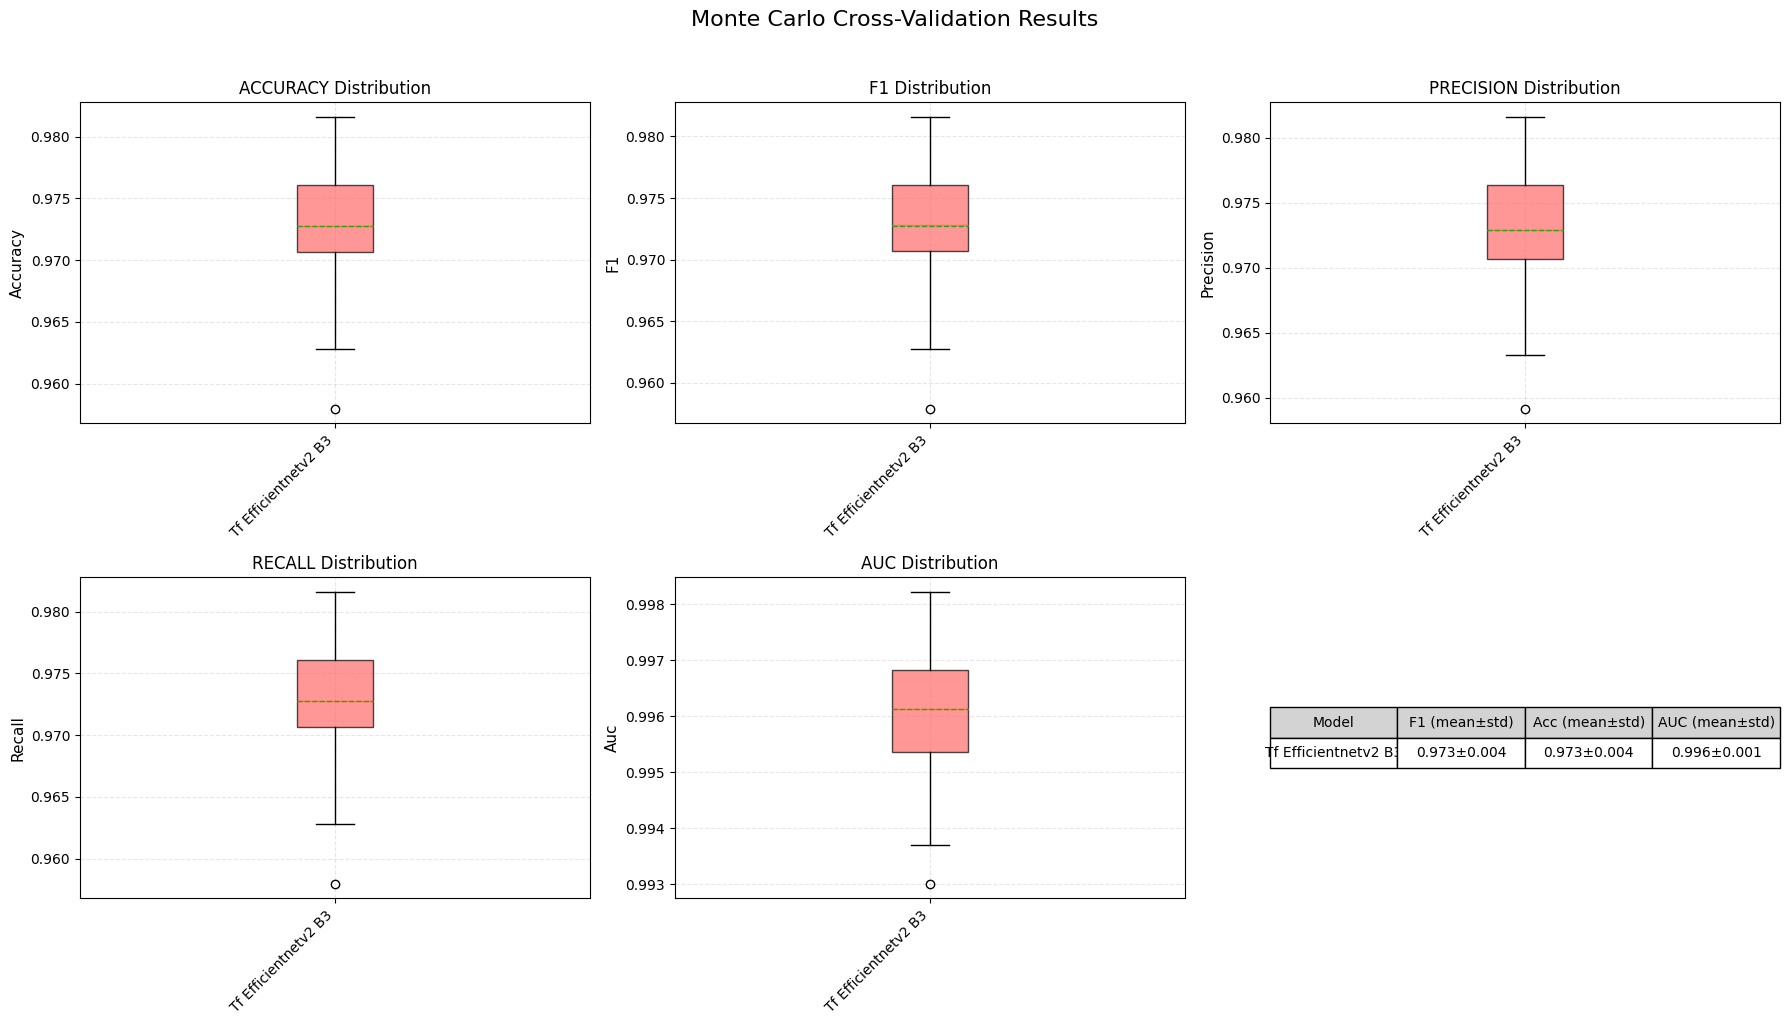

📊 Análise de convergência salva em: monte_carlo_results/convergence_analysis.png


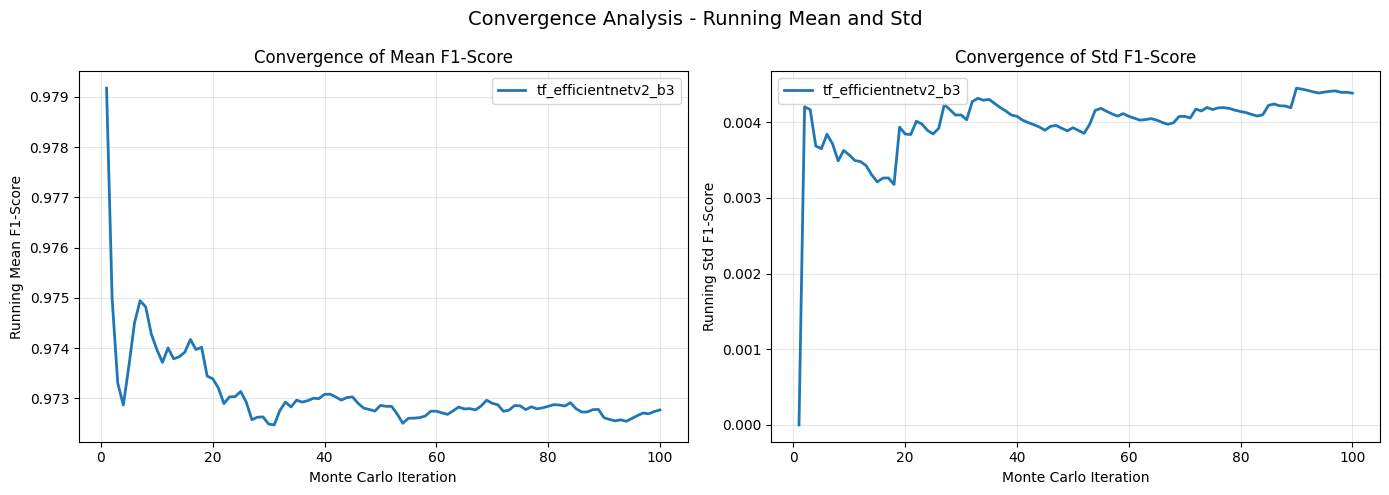

📄 Relatório salvo em: monte_carlo_results/monte_carlo_report.md

MONTE CARLO CROSS-VALIDATION CONCLUÍDO!
Resultados salvos em: monte_carlo_results


In [43]:
if __name__ == "__main__":
    main()